<a href="https://colab.research.google.com/github/Spandana331/AIML_2026/blob/main/module%202%20lab-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How do you think would the number of neighbors effect the Isomap algorithm? What happens when the number of neighbors considered is very large?
# What happens when it is very low? When is the ISOMAP algorithm superior to PCA?

In [2]:
import pandas as pd
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

df = pd.DataFrame(X)
df['label'] = y

df.to_csv("digits_dataset.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler

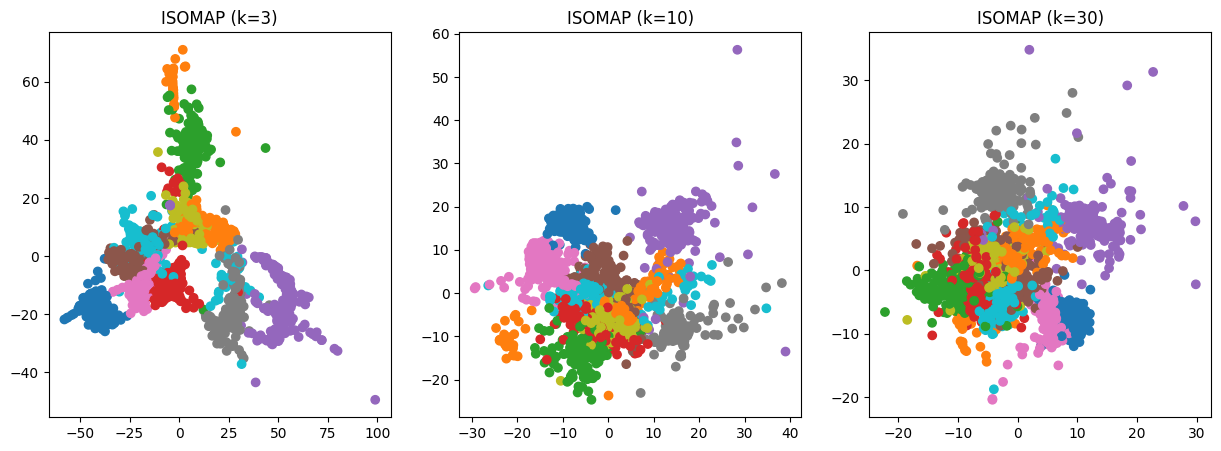

In [4]:
# Load dataset
df = pd.read_csv("digits_dataset.csv")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Different neighbor values
neighbors = [3, 10, 30]

plt.figure(figsize=(15,5))

for i, k in enumerate(neighbors):
    iso = Isomap(n_neighbors=k, n_components=2)
    X_iso = iso.fit_transform(X_scaled)

    plt.subplot(1,3,i+1)
    plt.scatter(X_iso[:,0], X_iso[:,1], c=y, cmap='tab10')
    plt.title(f"ISOMAP (k={k})")

plt.show()

k = 3 (low) → graph may be disconnected → scattered output
k = 10 (optimal) → clear clusters
k = 30 (high) → behaves like PCA → less nonlinear structure

# What happens when it is very low? When is the ISOMAP algorithm superior to PCA?

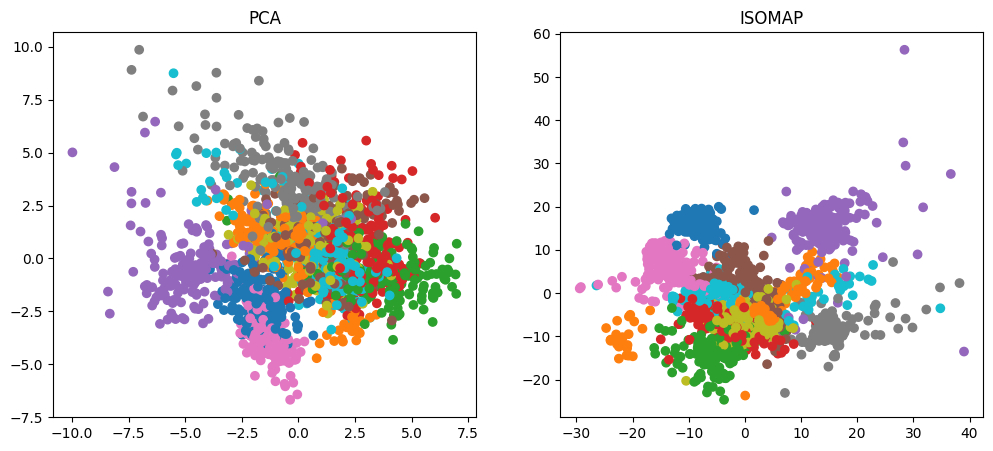

In [5]:
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# ISOMAP
iso = Isomap(n_neighbors=10, n_components=2)
X_iso = iso.fit_transform(X_scaled)

# Plot comparison
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10')
plt.title("PCA")

plt.subplot(1,2,2)
plt.scatter(X_iso[:,0], X_iso[:,1], c=y, cmap='tab10')
plt.title("ISOMAP")

plt.show()

PCA → captures only linear structure
ISOMAP → preserves nonlinear relationships
ISOMAP shows better cluster separation